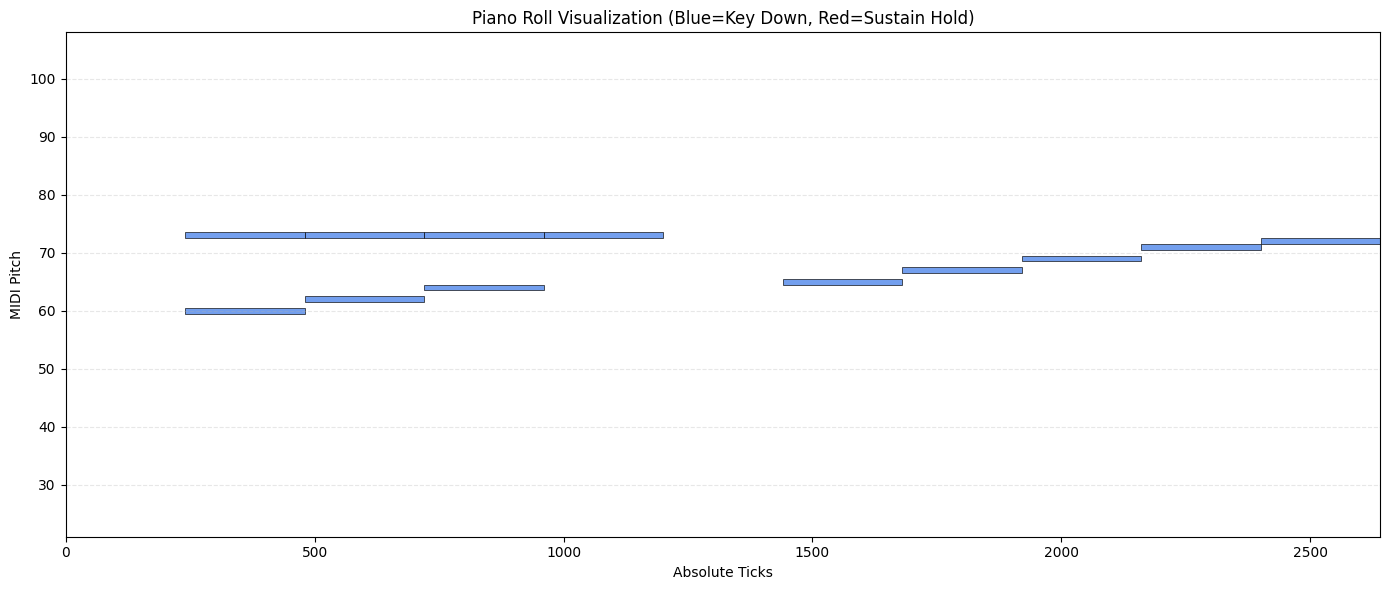

In [5]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Load the JSON produced by your Rust code
with open("output_chunks.json", "r") as f:
    chunks = json.load(f)

fig, ax = plt.subplots(figsize=(14, 6))

# 2. Iterate chunks and draw rectangles
# Each chunk represents a vertical "slice" of time where state is constant.
for chunk in chunks:
    t_start = chunk["start_tick"]
    duration = chunk["duration"]
    
    # Draw Keys Active (Blue)
    for note in chunk["keys_active"]:
        # Rectangle: (x, y), width, height
        rect = patches.Rectangle(
            (t_start, note - 0.5), duration, 1.0, 
            linewidth=0.5, edgecolor='black', facecolor='cornflowerblue', alpha=0.9
        )
        ax.add_patch(rect)

    # Draw Sustained Only (Red/Pink)
    for note in chunk["sustained_only"]:
        rect = patches.Rectangle(
            (t_start, note - 0.5), duration, 1.0, 
            linewidth=0.5, edgecolor='black', facecolor='salmon', alpha=0.9
        )
        ax.add_patch(rect)

# 3. Setup Plot Limits
if chunks:
    total_time = chunks[-1]["start_tick"] + chunks[-1]["duration"]
    ax.set_xlim(0, total_time)
    
ax.set_ylim(21, 108) # Standard Piano range (A0 to C8)
ax.set_xlabel("Absolute Ticks")
ax.set_ylabel("MIDI Pitch")
ax.set_title("Piano Roll Visualization (Blue=Key Down, Red=Sustain Hold)")

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

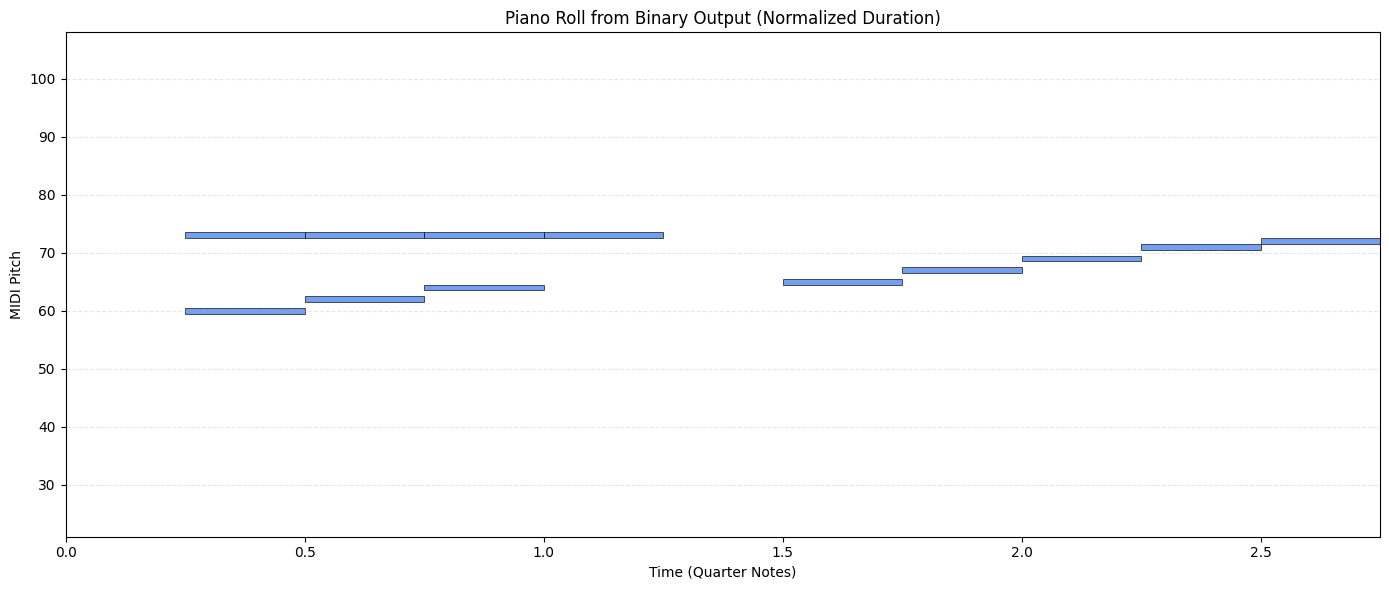

In [6]:
import struct
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuration
BINARY_FILE = "output.bin"
CHUNK_SIZE = 36  # 4 bytes (f32 duration) + 16 bytes (keys) + 16 bytes (sustained)

def bytes_to_notes(byte_array):
    """Converts a 16-byte bitmask into a list of MIDI note numbers."""
    notes = []
    for byte_index, byte in enumerate(byte_array):
        for bit_index in range(8):
            if (byte >> bit_index) & 1:
                # MIDI note = (byte_index * 8) + bit_pos
                notes.append(byte_index * 8 + bit_index)
    return notes

def load_binary_chunks(filename):
    chunks = []
    current_time = 0.0
    
    with open(filename, "rb") as f:
        while True:
            # Read exactly 36 bytes
            data = f.read(CHUNK_SIZE)
            if len(data) < CHUNK_SIZE:
                break  # End of file

            # 1. Unpack Duration (First 4 bytes, Little Endian Float <f)
            duration = struct.unpack('<f', data[0:4])[0]
            
            # 2. Unpack Bitmasks
            keys_mask = data[4:20]
            sustained_mask = data[20:36]
            
            # 3. Convert Masks to Note Lists
            keys_active = bytes_to_notes(keys_mask)
            sustained_only = bytes_to_notes(sustained_mask)
            
            chunks.append({
                "start": current_time,
                "duration": duration,
                "keys_active": keys_active,
                "sustained_only": sustained_only
            })
            
            # Advance time cursor
            current_time += duration
            
    return chunks

# --- Plotting Logic ---

chunks = load_binary_chunks(BINARY_FILE)

fig, ax = plt.subplots(figsize=(14, 6))

for chunk in chunks:
    t_start = chunk["start"]
    duration = chunk["duration"]
    
    # Draw Keys Active (Blue)
    for note in chunk["keys_active"]:
        rect = patches.Rectangle(
            (t_start, note - 0.5), duration, 1.0, 
            linewidth=0.5, edgecolor='black', facecolor='cornflowerblue', alpha=0.9
        )
        ax.add_patch(rect)

    # Draw Sustained Only (Red/Pink)
    for note in chunk["sustained_only"]:
        rect = patches.Rectangle(
            (t_start, note - 0.5), duration, 1.0, 
            linewidth=0.5, edgecolor='black', facecolor='salmon', alpha=0.9
        )
        ax.add_patch(rect)

# Setup Plot Limits
if chunks:
    total_time = chunks[-1]["start"] + chunks[-1]["duration"]
    ax.set_xlim(0, total_time)

ax.set_ylim(21, 108) # Standard Piano range
ax.set_xlabel("Time (Quarter Notes)") # Updated from 'Ticks' since we stored f32 quarters
ax.set_ylabel("MIDI Pitch")
ax.set_title("Piano Roll from Binary Output (Normalized Duration)")

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
from midiutil import MIDIFile

# Configuration
INPUT_BINARY = "output.bin"
OUTPUT_MIDI = "reconstructed.mid"
CHUNK_SIZE = 36  # 4 bytes duration + 16 bytes keys + 16 bytes sustained

def bytes_to_notes(byte_array):
    """Converts a 16-byte bitmask into a set of MIDI note numbers."""
    notes = set()
    for byte_index, byte in enumerate(byte_array):
        for bit_index in range(8):
            if (byte >> bit_index) & 1:
                notes.add(byte_index * 8 + bit_index)
    return notes

def binary_to_midi_stitching():
    # Create MIDI object with 2 tracks
    # Track 0: Physical Keys (Channel 0)
    # Track 1: Sustained Notes (Channel 0, lower velocity)
    midi = MIDIFile(2)
    midi.addTrackName(0, 0, "Keys Active")
    midi.addTrackName(1, 0, "Sustained Only")
    midi.addTempo(0, 0, 120) 

    # State tracking for stitching sliced chunks back into long notes
    # Dictionary format: { pitch: start_time_in_quarters }
    active_keys = {}
    active_sustains = {}
    
    current_time = 0.0

    with open(INPUT_BINARY, "rb") as f:
        while True:
            data = f.read(CHUNK_SIZE)
            if len(data) < CHUNK_SIZE:
                break

            # 1. Parse Chunk
            duration = struct.unpack('<f', data[0:4])[0]
            keys_mask = data[4:20]
            sust_mask = data[20:36]

            # Get set of notes active in this time slice
            current_keys_set = bytes_to_notes(keys_mask)
            current_sust_set = bytes_to_notes(sust_mask)

            # --- Logic for Track 0 (Physical Keys) ---
            # A. Check for notes that ended (Were active, now are not)
            # Use list(keys) to avoid runtime error while modifying dict
            for pitch in list(active_keys.keys()):
                if pitch not in current_keys_set:
                    # Note Ended! Write it to MIDI.
                    start_t = active_keys[pitch]
                    note_dur = current_time - start_t
                    # addNote(track, channel, pitch, time, duration, volume)
                    midi.addNote(0, 0, pitch, start_t, note_dur, 100)
                    del active_keys[pitch]

            # B. Check for notes that started (Are active, were not before)
            for pitch in current_keys_set:
                if pitch not in active_keys:
                    active_keys[pitch] = current_time

            # --- Logic for Track 1 (Sustained Only) ---
            # We do the same logic but for the "Sustained" voice
            for pitch in list(active_sustains.keys()):
                if pitch not in current_sust_set:
                    start_t = active_sustains[pitch]
                    note_dur = current_time - start_t
                    # Track 1, Velocity 60 (Softer, ghost-like)
                    midi.addNote(1, 0, pitch, start_t, note_dur, 60)
                    del active_sustains[pitch]

            for pitch in current_sust_set:
                if pitch not in active_sustains:
                    active_sustains[pitch] = current_time

            # Advance time
            current_time += duration

    # End of File: Close any notes still ringing
    for pitch, start_t in active_keys.items():
        midi.addNote(0, 0, pitch, start_t, current_time - start_t, 100)
    
    for pitch, start_t in active_sustains.items():
        midi.addNote(1, 0, pitch, start_t, current_time - start_t, 60)

    # Save to file
    with open(OUTPUT_MIDI, "wb") as output_file:
        midi.writeFile(output_file)
    
    print(f"Reconstructed MIDI saved to {OUTPUT_MIDI}")

ModuleNotFoundError: No module named 'midiutil'